# Notebook 2 — Conectividad Funcional y Métricas de Grafos
**Proyecto:** Reorganización topológica de redes cerebrales y envejecimiento acelerado (ReDLaT / IIPSI)

**Prerequisito:** haber ejecutado el Notebook 1. Las matrices FC ya están pre-computadas en `data-iipsi`; no se requiere fMRIPrep ni archivos NIfTI crudos.

**Pasos:**
1. Configurar rutas y cargar cohorte elegible
2. Configurar atlas AAL-116
3. Cargar matrices FC desde archivos `.mat` y aplicar Fisher-z
4. Umbralización por umbral fijo y construcción de grafos binarios
5. Métricas de teoría de grafos (eficiencia, clustering, betweenness)
6. Visualizaciones topológicas
7. Volumetría de materia gris (VBM desde CSV pre-computado)
8. Guardar resultados para Notebooks 3 y 4

In [49]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import re
import h5py
from pathlib import Path
from scipy.io import loadmat

from nilearn import plotting
from nilearn.datasets import fetch_atlas_aal
from nilearn.regions import signals_to_img_labels

import networkx as nx
import bct

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

for d in ['outputs/fc_matrices', 'outputs/graph_metrics', 'figs']:
    Path(d).mkdir(parents=True, exist_ok=True)

DATA_ROOT = Path('data-iipsi/data')
FC_DIR    = DATA_ROOT / 'matrices-redlat' / 'matrices-redlat'
T1W_CSV   = DATA_ROOT / 'Redlat_VGM_AAL_.csv'

THRESHOLD = 0.20   # umbral fijo de binarización Fisher-z
print('Umbral fijo:', THRESHOLD)

Umbral fijo: 0.2


## 1. Cargar cohorte elegible

In [50]:
eligible = pd.read_csv('outputs/eligible_fc_subjects.csv')
print(f'Sujetos elegibles: {len(eligible)}')
print(eligible[['MRI_ID', 'diagnosis', 'Age', 'site']].head(10))

Sujetos elegibles: 1327
    MRI_ID diagnosis   Age     site
0    AF025        CN  75.0    Avila
1    AF036        AD  74.0    Avila
2    AF037       FTD  71.0    Avila
3    AF063        CN  73.0    Avila
4    AF065        CN  65.0    Avila
5    AF075        CN  19.0    Avila
6    AF098        AD  80.0    Avila
7    AF114       FTD  72.0    Avila
8    AF119        CN  32.0    Avila
9  BE00132        AD  68.0  Behrens


## 2. Atlas AAL-116

[fetch_atlas_aal] Dataset found in C:\Users\Admin\nilearn_data\aal_SPM12

Atlas AAL: 117 regiones
Primeras 10 etiquetas: ['Background', 'Precentral_L', 'Precentral_R', 'Frontal_Sup_L', 'Frontal_Sup_R', 'Frontal_Sup_Orb_L', 'Frontal_Sup_Orb_R', 'Frontal_Mid_L', 'Frontal_Mid_R', 'Frontal_Mid_Orb_L']


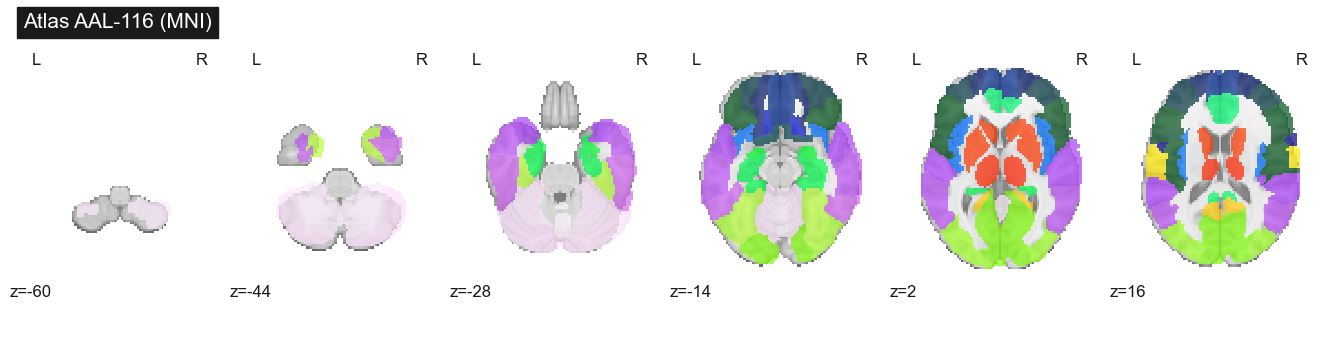


ROIs frontoparietales seleccionadas:
  [  2] Precentral_R
  [  3] Frontal_Sup_L
  [  6] Frontal_Sup_Orb_R
  [  7] Frontal_Mid_L
  [ 32] Cingulum_Ant_R
  [ 33] Cingulum_Mid_L
  [ 60] Parietal_Sup_R
  [ 61] Parietal_Inf_L
  [ 62] Parietal_Inf_R
  [ 63] SupraMarginal_L
  [ 66] Angular_R
  [ 67] Precuneus_L
  [ 80] Heschl_R
  [ 81] Temporal_Sup_L


In [51]:
aal = fetch_atlas_aal(version='SPM12')
print(f'Atlas AAL: {len(aal.labels)} regiones')
print('Primeras 10 etiquetas:', aal.labels[:10])

plotting.plot_roi(aal.maps, title='Atlas AAL-116 (MNI)',
                  display_mode='z', cut_coords=6, colorbar=False)
plt.savefig('figs/02_atlas_AAL116.png', dpi=150)
plt.show()

# ROIs frontoparietales (índices 0-based en aal.labels)
FRONTOPARIETAL_IDX = [2,3,6,7,32,33,60,61,62,63,66,67,80,81]
fp_labels = [aal.labels[i] for i in FRONTOPARIETAL_IDX]
print('\nROIs frontoparietales seleccionadas:')
for i, lbl in zip(FRONTOPARIETAL_IDX, fp_labels):
    print(f'  [{i:3d}] {lbl}')

## 3. Carga de matrices FC desde archivos .mat

Cada `.mat` contiene la clave `c` con la matriz de correlaciones de Pearson 116×116 ya computada.
Se aplica Fisher-z para estabilizar la varianza antes de cualquier análisis.

In [52]:
def extract_mat_id(filename: str) -> str:
    """sub-AF025_timeseries.mat → AF025"""
    m = re.search(r'sub-([A-Za-z0-9]+)_timeseries', filename, re.IGNORECASE)
    return m.group(1).upper() if m else ''

def load_fc_mat(path: Path) -> np.ndarray:
    """Carga la matriz FC (clave 'c'), fuerza diagonal=1."""
    md  = loadmat(str(path))
    mat = np.array(md['c'], dtype=np.float64)
    np.fill_diagonal(mat, 1.0)
    return mat

def fisher_z(fc: np.ndarray) -> np.ndarray:
    """Fisher-z: arctanh clipeado, diagonal = 0."""
    fz = np.arctanh(np.clip(fc, -0.9999, 0.9999))
    np.fill_diagonal(fz, 0.0)
    return fz

# Índice ID → archivo .mat
id_to_path = {extract_mat_id(f.name): f for f in FC_DIR.glob('*.mat')}
id_to_path.pop('', None)
print(f'Archivos .mat indexados: {len(id_to_path)}')

Archivos .mat indexados: 1365


In [53]:
all_fc_z = {}
failed   = []

for _, row in eligible.iterrows():
    sub_id = row['MRI_ID']
    if sub_id not in id_to_path:
        failed.append(sub_id)
        continue
    try:
        fc      = load_fc_mat(id_to_path[sub_id])
        fc_z    = fisher_z(fc)
        all_fc_z[sub_id] = fc_z
        np.save(f'outputs/fc_matrices/{sub_id}_fc_z.npy', fc_z)
    except Exception as e:
        print(f'[ERROR] {sub_id}: {e}')
        failed.append(sub_id)

print(f'Cargadas: {len(all_fc_z)} | Fallidas: {len(failed)}')
if failed[:5]:
    print('Primeros fallidos:', failed[:5])

Cargadas: 1327 | Fallidas: 0


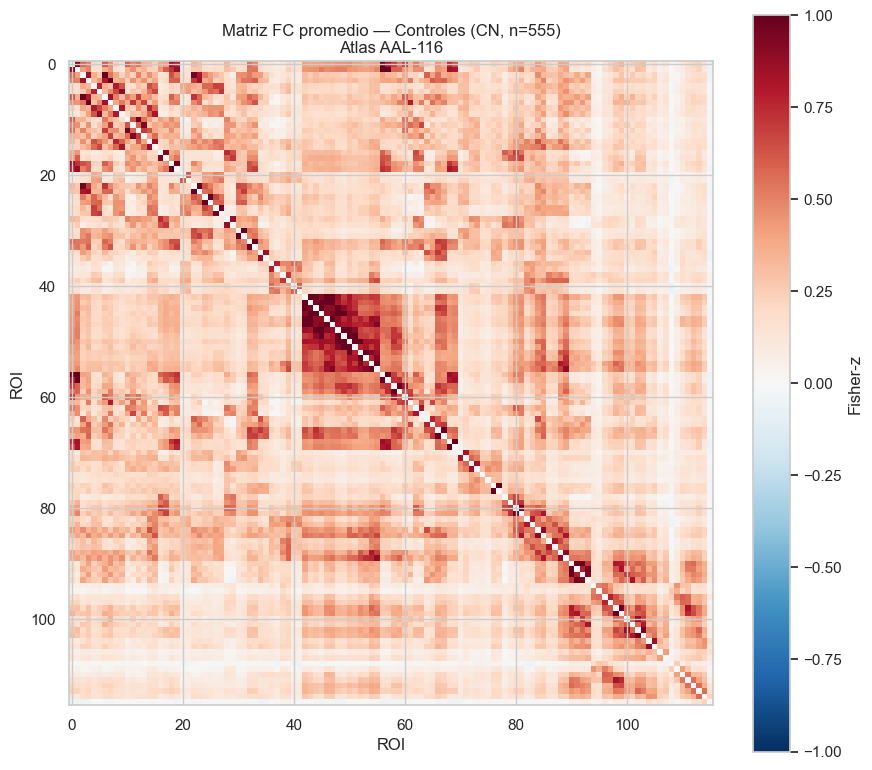

In [54]:
# FC matrix promedio del grupo CN
cn_ids     = eligible[eligible['diagnosis'] == 'CN']['MRI_ID'].tolist()
fc_cn_list = [all_fc_z[s] for s in cn_ids if s in all_fc_z]

if fc_cn_list:
    fc_cn_mean = np.mean(fc_cn_list, axis=0)
    fig, ax = plt.subplots(figsize=(9, 8))
    im = ax.imshow(fc_cn_mean, cmap='RdBu_r', vmin=-1, vmax=1, interpolation='nearest')
    plt.colorbar(im, ax=ax, label='Fisher-z')
    ax.set_title(f'Matriz FC promedio — Controles (CN, n={len(fc_cn_list)})\nAtlas AAL-116')
    ax.set_xlabel('ROI'); ax.set_ylabel('ROI')
    plt.tight_layout()
    plt.savefig('figs/02_fc_matrix_CN_mean.png', dpi=150)
    plt.show()

## 4. Umbralización — umbral fijo Fisher-z = 0.20

In [55]:
def threshold_fixed(fc_matrix: np.ndarray, threshold: float) -> np.ndarray:
    """Retorna matriz binaria simétrica conservando Fisher-z >= threshold."""
    mat = fc_matrix.copy()
    np.fill_diagonal(mat, 0)
    binary = (mat >= threshold).astype(float)
    return np.maximum(binary, binary.T)

# Verificación con un sujeto ejemplo
example_id  = list(all_fc_z.keys())[0]
example_mat = all_fc_z[example_id]
print(f'Ejemplo: {example_id}')
for thr in [0.20, 0.30, 0.40]:
    bmat    = threshold_fixed(example_mat, thr)
    n_conn  = int(bmat.sum() / 2)
    density = n_conn / (116 * 115 / 2)
    print(f'  Umbral {thr:.2f}: {n_conn} conexiones  (densidad = {density:.3f})')

Ejemplo: AF025
  Umbral 0.20: 738 conexiones  (densidad = 0.111)
  Umbral 0.30: 186 conexiones  (densidad = 0.028)
  Umbral 0.40: 33 conexiones  (densidad = 0.005)


## 5. Métricas de teoría de grafos

In [56]:
def compute_graph_metrics(binary_matrix: np.ndarray, fp_idx: list) -> dict:
    """Calcula métricas topológicas globales y de hubs frontoparietales."""
    n = binary_matrix.shape[0]
    B = binary_matrix.astype(float)

    local_eff_nodes  = bct.efficiency_bin(B, local=True)
    global_eff       = bct.efficiency_bin(B, local=False)
    clustering_nodes = bct.clustering_coef_bu(B)
    degree_norm      = np.sum(B, axis=0) / (n - 1)
    betweenness      = bct.betweenness_bin(B)
    betweenness_norm = betweenness / ((n-1) * (n-2))

    return {
        'local_efficiency':    float(np.mean(local_eff_nodes)),
        'global_efficiency':   float(global_eff),
        'clustering_coeff':    float(np.mean(clustering_nodes)),
        'degree_mean':         float(np.mean(degree_norm)),
        'betweenness_mean':    float(np.mean(betweenness_norm)),
        'fp_local_efficiency': float(np.mean(local_eff_nodes[fp_idx])),
        'fp_betweenness':      float(np.mean(betweenness_norm[fp_idx])),
        'fp_degree':           float(np.mean(degree_norm[fp_idx])),
        '_local_eff_nodes':    local_eff_nodes,
        '_betweenness_nodes':  betweenness_norm,
        '_degree_nodes':       degree_norm,
    }

In [57]:
# Bucle principal — un cómputo por sujeto al umbral fijo
graph_records = []
n_total = len(all_fc_z)

for i, (sub_id, fc_z) in enumerate(all_fc_z.items()):
    row_demo = eligible[eligible['MRI_ID'] == sub_id].iloc[0]
    bmat     = threshold_fixed(fc_z, THRESHOLD)
    metrics  = compute_graph_metrics(bmat, FRONTOPARIETAL_IDX)

    record = {
        'MRI_ID':          sub_id,
        'diagnosis':       row_demo['diagnosis'],
        'Age':             row_demo['Age'],
        'sex':             row_demo.get('sex', np.nan),
        'years_education': row_demo.get('years_education', np.nan),
        'site':            row_demo['site'],
    }
    record.update({k: v for k, v in metrics.items() if not k.startswith('_')})
    graph_records.append(record)

    if (i + 1) % 100 == 0:
        print(f'[{i+1}/{n_total}] {sub_id} ✓')

graph_df = pd.DataFrame(graph_records)
print(f'\nMétricas computadas para {len(graph_df)} sujetos (umbral={THRESHOLD})')
graph_df.head()

[100/1327] BN00078 ✓
[200/1327] LO00501 ✓
[300/1327] MA248 ✓
[400/1327] MA622 ✓
[500/1327] SL00429 ✓
[600/1327] MI00145 ✓
[700/1327] MI00303 ✓
[800/1327] MI00432 ✓
[900/1327] MI00581 ✓
[1000/1327] TA0123 ✓
[1100/1327] PIB00082 ✓
[1200/1327] PMA092 ✓
[1300/1327] PSL00080 ✓

Métricas computadas para 1327 sujetos (umbral=0.2)


,MRI_ID,diagnosis,Age,sex,years_education,site,local_efficiency,global_efficiency,clustering_coeff,degree_mean,betweenness_mean,fp_local_efficiency,fp_betweenness,fp_degree
0,AF025,CN,75.0,2,16.0,Avila,0.462357,0.497589,0.252725,0.110645,0.010893,0.469715,0.014237,0.122360
1,AF036,AD,74.0,2,11.0,Avila,0.519623,0.514963,0.293371,0.138681,0.009958,0.651292,0.012792,0.182609
2,AF037,FTD,71.0,1,17.0,Avila,0.625286,0.562081,0.388319,0.180360,0.008680,0.700909,0.010290,0.242236
3,AF063,CN,73.0,2,NaN,Avila,0.670525,0.590115,0.498113,0.246927,0.008458,0.744686,0.010216,0.319876
4,AF065,CN,65.0,1,NaN,Avila,0.646028,0.580622,0.416398,0.207646,0.008175,0.689290,0.010549,0.262733


## 6. Visualizaciones topológicas

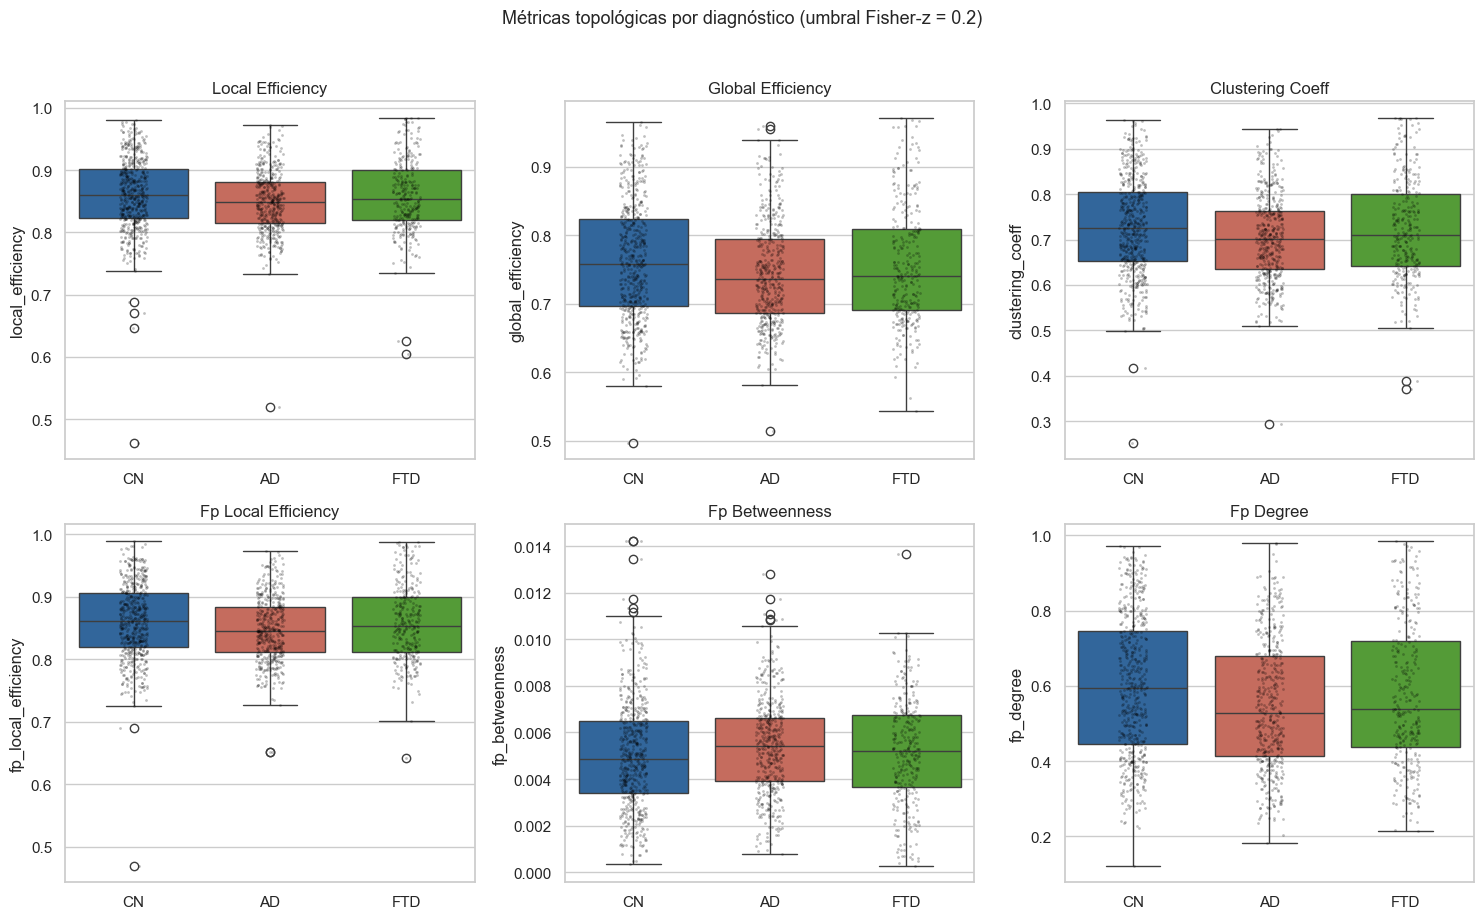

In [58]:
METRIC_COLS = ['local_efficiency', 'global_efficiency', 'clustering_coeff',
               'fp_local_efficiency', 'fp_betweenness', 'fp_degree']
COLORS = {'CN': '#2166ac', 'AD': '#d6604d', 'FTD': '#4dac26'}

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for ax, col in zip(axes.ravel(), METRIC_COLS):
    sub = graph_df[graph_df.diagnosis.isin(['CN', 'AD', 'FTD'])]
    sns.boxplot(data=sub, x='diagnosis', y=col,
                order=['CN', 'AD', 'FTD'], palette=COLORS, ax=ax)
    sns.stripplot(data=sub, x='diagnosis', y=col,
                  order=['CN', 'AD', 'FTD'], color='black', alpha=0.25, size=2, ax=ax)
    ax.set_title(col.replace('_', ' ').title())
    ax.set_xlabel('')

plt.suptitle(f'Métricas topológicas por diagnóstico (umbral Fisher-z = {THRESHOLD})',
             y=1.02, fontsize=13)
plt.tight_layout()
plt.savefig('figs/02_graph_metrics_by_diagnosis.png', dpi=150)
plt.show()

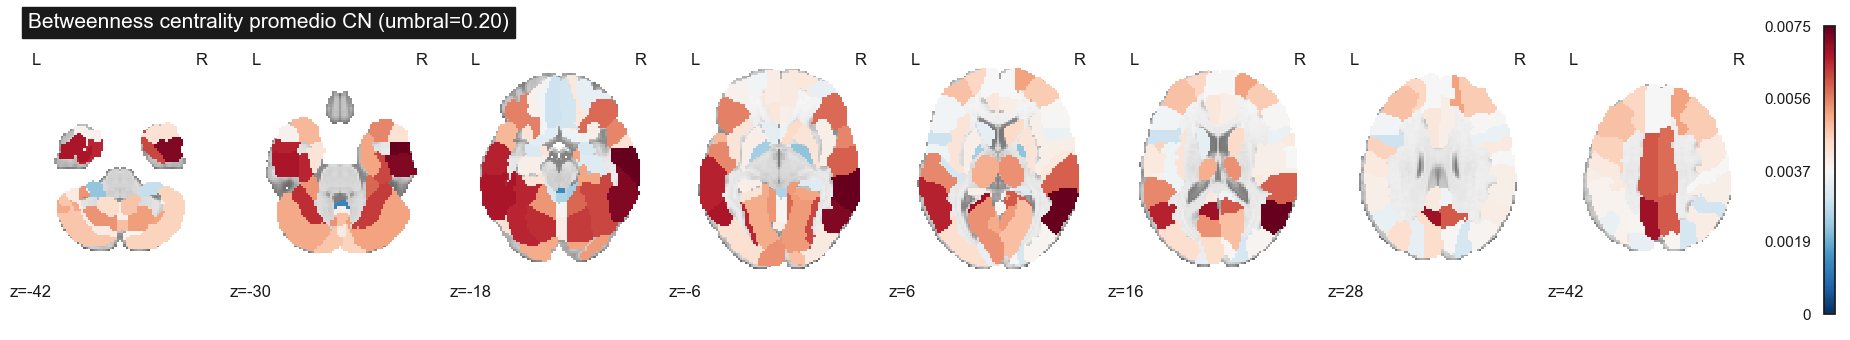

In [59]:
# Betweenness centrality promedio de CN proyectado sobre el cerebro
bc_cn_nodes = []
for sub_id in cn_ids:
    if sub_id not in all_fc_z:
        continue
    bmat = threshold_fixed(all_fc_z[sub_id], 0.20)
    m    = compute_graph_metrics(bmat, FRONTOPARIETAL_IDX)
    bc_cn_nodes.append(m['_betweenness_nodes'])

if bc_cn_nodes:
    bc_mean = np.mean(bc_cn_nodes, axis=0)  # (116,)
    bc_img  = signals_to_img_labels(bc_mean[np.newaxis, :], aal.maps)
    plotting.plot_stat_map(
        bc_img, display_mode='z', cut_coords=8,
        title='Betweenness centrality promedio CN (umbral=0.20)',
        colorbar=True
    )
    plt.savefig('figs/02_betweenness_brain_CN.png', dpi=150)
    plt.show()

## 7. Volumetría de materia gris (VBM desde CSV)

`Redlat_VGM_AAL_.csv` contiene la probabilidad media de GM por ROI del atlas AAL para cada sujeto,
ya extraída con CAT12. Primera columna = ID en formato `cat_sub-AF025_T1w.xml`.

In [60]:
def extract_t1w_id(raw_id: str) -> str:
    """cat_sub-AF025_T1w.xml → AF025"""
    s = str(raw_id).upper()
    s = re.sub(r'CAT_SUB-|SUB-', '', s)
    s = re.sub(r'_T1W.*|_SES.*', '', s)
    m = re.match(r'([A-Z]{2,5}\d{2,6})', s)
    return m.group(1) if m else s

t1w_raw = pd.read_csv(T1W_CSV, header=None)
t1w_raw[0] = t1w_raw[0].apply(extract_t1w_id)

# El CSV tiene 116 ROIs; aal.labels incluye 'Background' → excluirlo
roi_labels = [lbl for lbl in aal.labels if lbl.lower() != 'background']
feat_cols = [f'gm_{lbl}' for lbl in roi_labels]

n_rois_csv = t1w_raw.shape[1] - 1
assert n_rois_csv == len(feat_cols), (
    f'CSV: {n_rois_csv} ROIs, atlas (sin Background): {len(feat_cols)}'
)

t1w_raw.columns = ['MRI_ID'] + feat_cols

# Colapsar duplicados (mismo sujeto, varias entradas → promedio)
t1w_df = t1w_raw.groupby('MRI_ID', as_index=False)[feat_cols].mean()
t1w_df['gm_total'] = t1w_df[feat_cols].sum(axis=1)

# Usar nombres de ROI (fp_labels viene de la celda del atlas AAL)
fp_feat_cols = [f'gm_{lbl}' for lbl in fp_labels]
t1w_df['gm_fp_mean'] = t1w_df[fp_feat_cols].mean(axis=1)

vbm_df = eligible[['MRI_ID', 'diagnosis', 'Age', 'site']].merge(
    t1w_df[['MRI_ID', 'gm_total', 'gm_fp_mean'] + feat_cols],
    on='MRI_ID',
    how='inner',
)

print(f'VBM disponible: {len(vbm_df)} sujetos de {len(eligible)} elegibles')
vbm_df[['gm_total', 'gm_fp_mean']].describe().round(4)

VBM disponible: 1245 sujetos de 1327 elegibles


,gm_total,gm_fp_mean
count,1245.0000,1245.0000
mean,0.3561,0.0039
std,0.0335,0.0004
min,0.2363,0.0024
25%,0.3333,0.0036
50%,0.3572,0.0039
75%,0.3810,0.0042
max,0.4636,0.0054


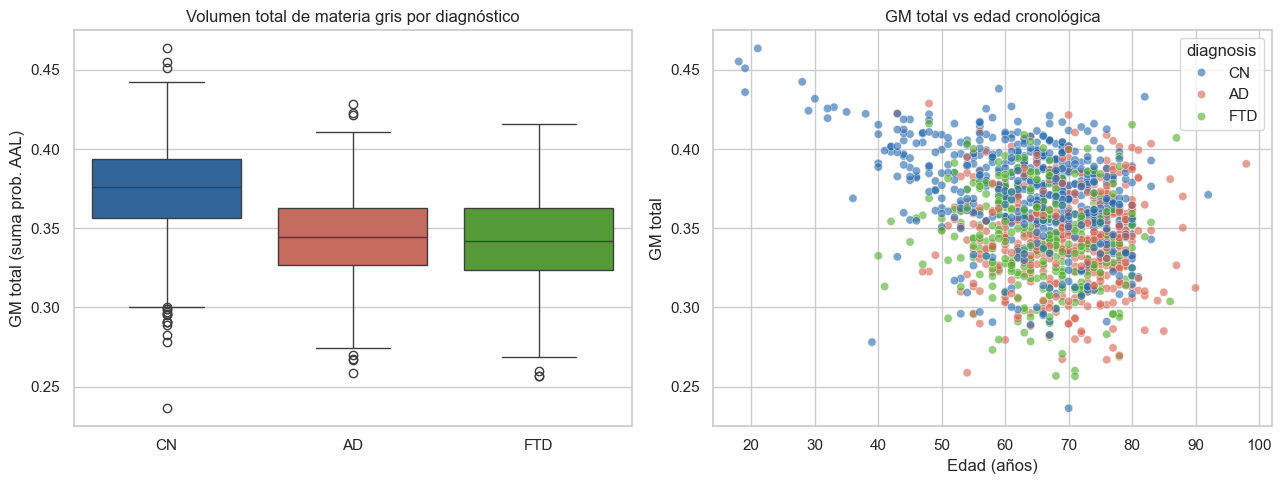

In [61]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.boxplot(data=vbm_df[vbm_df.diagnosis.isin(['CN','AD','FTD'])],
            x='diagnosis', y='gm_total', order=['CN','AD','FTD'],
            palette=COLORS, ax=axes[0])
axes[0].set_title('Volumen total de materia gris por diagnóstico')
axes[0].set_ylabel('GM total (suma prob. AAL)')
axes[0].set_xlabel('')

sns.scatterplot(data=vbm_df[vbm_df.diagnosis.isin(['CN','AD','FTD'])],
                x='Age', y='gm_total', hue='diagnosis', palette=COLORS,
                hue_order=['CN','AD','FTD'], alpha=0.6, ax=axes[1])
axes[1].set_title('GM total vs edad cronológica')
axes[1].set_xlabel('Edad (años)')
axes[1].set_ylabel('GM total')

plt.tight_layout()
plt.savefig('figs/02_vbm_gm_volume.png', dpi=150)
plt.show()

## 8. Guardar outputs para Notebooks 3 y 4

In [62]:
graph_df.to_csv('outputs/graph_metrics_table.csv', index=False)
vbm_df.to_csv('outputs/vbm_features.csv', index=False)

with h5py.File('outputs/all_fc_matrices.h5', 'w') as f:
    for sub_id, fc_z in all_fc_z.items():
        f.create_dataset(sub_id, data=fc_z, compression='gzip')

print('Archivos guardados:')
print('  outputs/graph_metrics_table.csv   — métricas topológicas por sujeto (umbral=0.20)')
print('  outputs/vbm_features.csv          — volumetría GM por ROI AAL')
print('  outputs/all_fc_matrices.h5        — todas las FC matrices (Fisher-z)')
print('  outputs/fc_matrices/{id}_fc_z.npy — una por sujeto (para notebook 04)')
print(f'\nColumnas graph_metrics_table: {list(graph_df.columns)}')

Archivos guardados:
  outputs/graph_metrics_table.csv   — métricas topológicas por sujeto (umbral=0.20)
  outputs/vbm_features.csv          — volumetría GM por ROI AAL
  outputs/all_fc_matrices.h5        — todas las FC matrices (Fisher-z)
  outputs/fc_matrices/{id}_fc_z.npy — una por sujeto (para notebook 04)

Columnas graph_metrics_table: ['MRI_ID', 'diagnosis', 'Age', 'sex', 'years_education', 'site', 'local_efficiency', 'global_efficiency', 'clustering_coeff', 'degree_mean', 'betweenness_mean', 'fp_local_efficiency', 'fp_betweenness', 'fp_degree']
